In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from IPython.display import display

full_data = pd.read_csv(r"../../data/processed/data_final_shift.csv",
                        index_col="Date", parse_dates=True).sort_index()

def check_multicollinearity(data, target_col=None):
    """
    데이터프레임을 입력받아 상관계수 히트맵과 VIF 수치를 출력하는 함수
    
    :param data: 분석할 pandas DataFrame
    :param target_col: 제외할 타겟 변수명 (문자열, 생략 가능)
    :return: VIF 결과가 담긴 DataFrame
    """
    print("=" * 50)
    print("🚀 다중공선성(Multicollinearity) 분석 시작")
    print("=" * 50)
    
    # 1. 데이터 전처리 (타겟 제외 -> 숫자형 추출 -> 결측치/무한대 제거)
    if target_col and target_col in data.columns:
        df = data.drop(columns=[target_col])
    else:
        df = data.copy()
        
    X = (df.select_dtypes(include=[np.number])
           .replace([np.inf, -np.inf], np.nan)
           .dropna())
           
    print(f"✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): {X.shape}\n")
    
    # 2. 피어슨 상관계수 히트맵
    plt.figure(figsize=(16, 12))
    corr_matrix = X.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title("Feature Correlation Heatmap", fontsize=16)
    plt.show()
    
    # 3. 분산팽창지수 (VIF) 계산
    X_vif = add_constant(X)
    vif_df = pd.DataFrame({
        "Feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    }).query("Feature != 'const'").sort_values(by="VIF", ascending=False).reset_index(drop=True)
    
    pd.options.display.float_format = '{:.4f}'.format
    
    print("\n[ 📊 변수별 VIF 결과 ]")
    display(vif_df)
    
    # 4. 위험 변수 목록 출력
    high_vif = vif_df[vif_df["VIF"] >= 10]['Feature'].tolist()
    print("\n🚨 VIF 10 이상인 위험 변수 목록:")
    if high_vif:
        print(high_vif)
    else:
        print("위험 수준의 변수가 없습니다. (모든 VIF 10 미만)")

## 전체 데이터에서 VIF 확인 (full_data)

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 44)



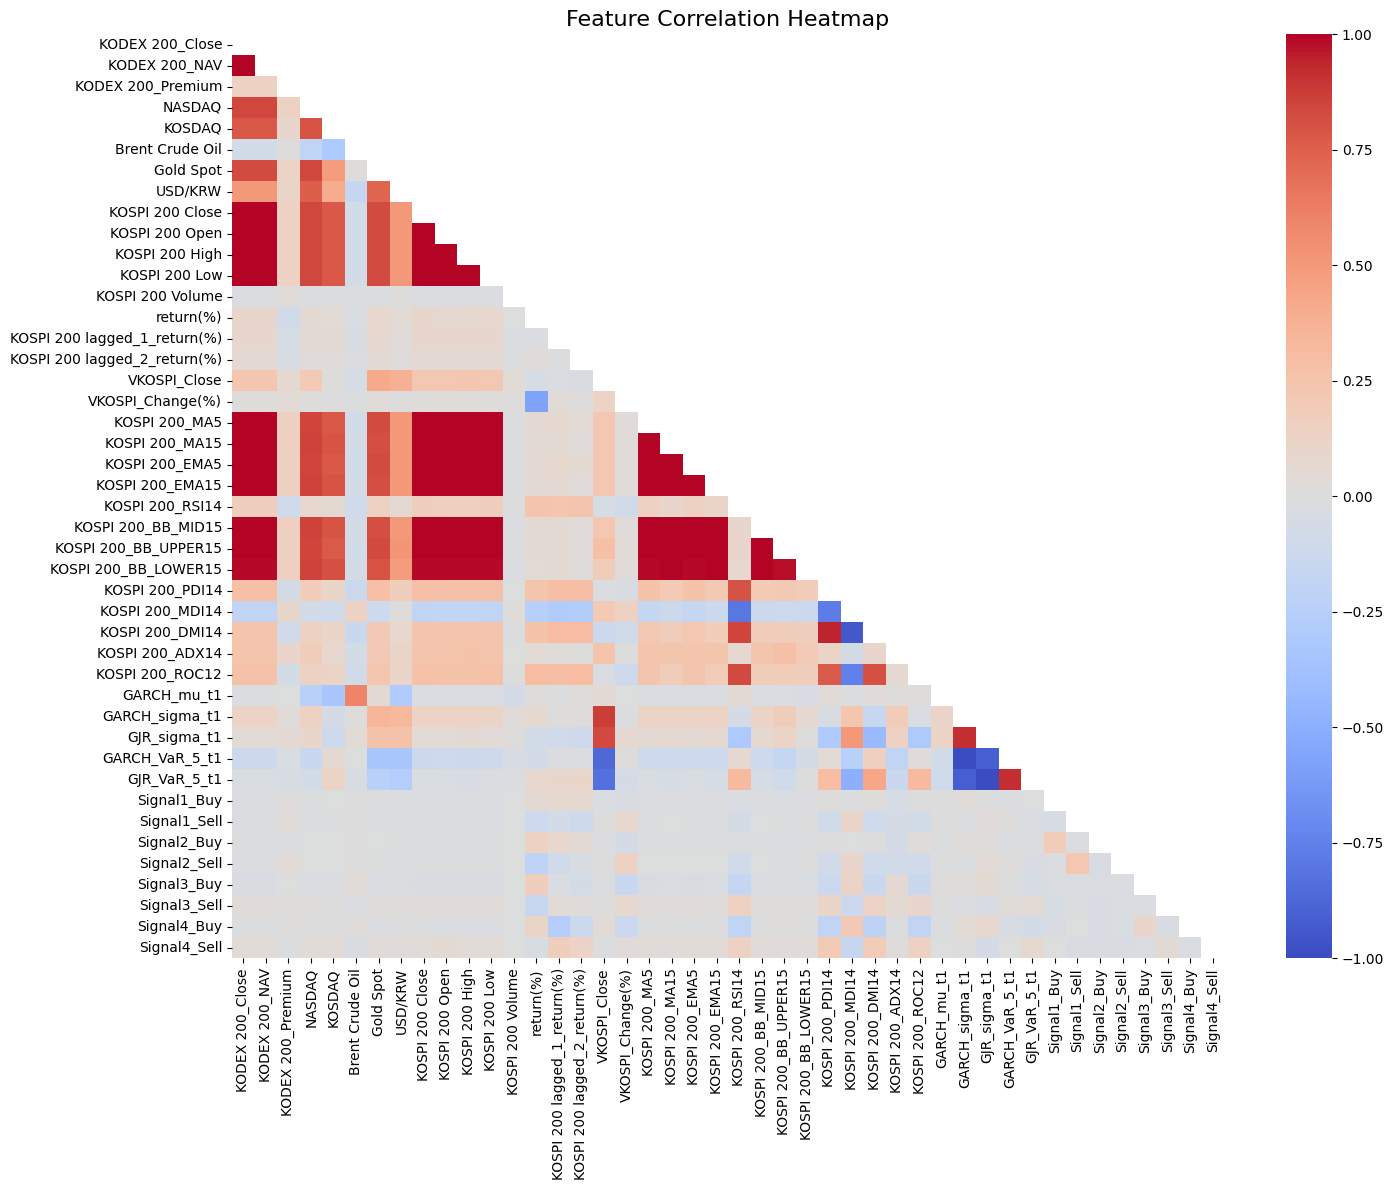


[ 📊 변수별 VIF 결과 ]


c:\Users\Owner\OneDrive\Labtop\KDISS\TS_RL_proj\venv_dt\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,KOSPI 200_BB_MID15,inf
1,KOSPI 200_BB_LOWER15,inf
2,KOSPI 200_MA15,inf
3,KOSPI 200_BB_UPPER15,9007199254740992.0000
4,KOSPI 200_PDI14,428914250225761.5000
5,KOSPI 200_MDI14,225179981368524.8125
6,KOSPI 200_DMI14,214457125112880.7500
7,KODEX 200_Close,519468.7935
8,KODEX 200_NAV,512939.2025
9,KOSPI 200_EMA5,94042.1584



🚨 VIF 10 이상인 위험 변수 목록:
['KOSPI 200_BB_MID15', 'KOSPI 200_BB_LOWER15', 'KOSPI 200_MA15', 'KOSPI 200_BB_UPPER15', 'KOSPI 200_PDI14', 'KOSPI 200_MDI14', 'KOSPI 200_DMI14', 'KODEX 200_Close', 'KODEX 200_NAV', 'KOSPI 200_EMA5', 'KOSPI 200_MA5', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200 Close', 'KOSPI 200_EMA15', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'NASDAQ', 'KODEX 200_Premium', 'Gold Spot', 'GARCH_mu_t1', 'KOSPI 200_ROC12']


In [2]:
check_multicollinearity(full_data, target_col='Risk_Label')

### 볼린저 밴드 폭(BBwidth) 변수 생성 및 VIF 확인 (full_data_a)

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 42)



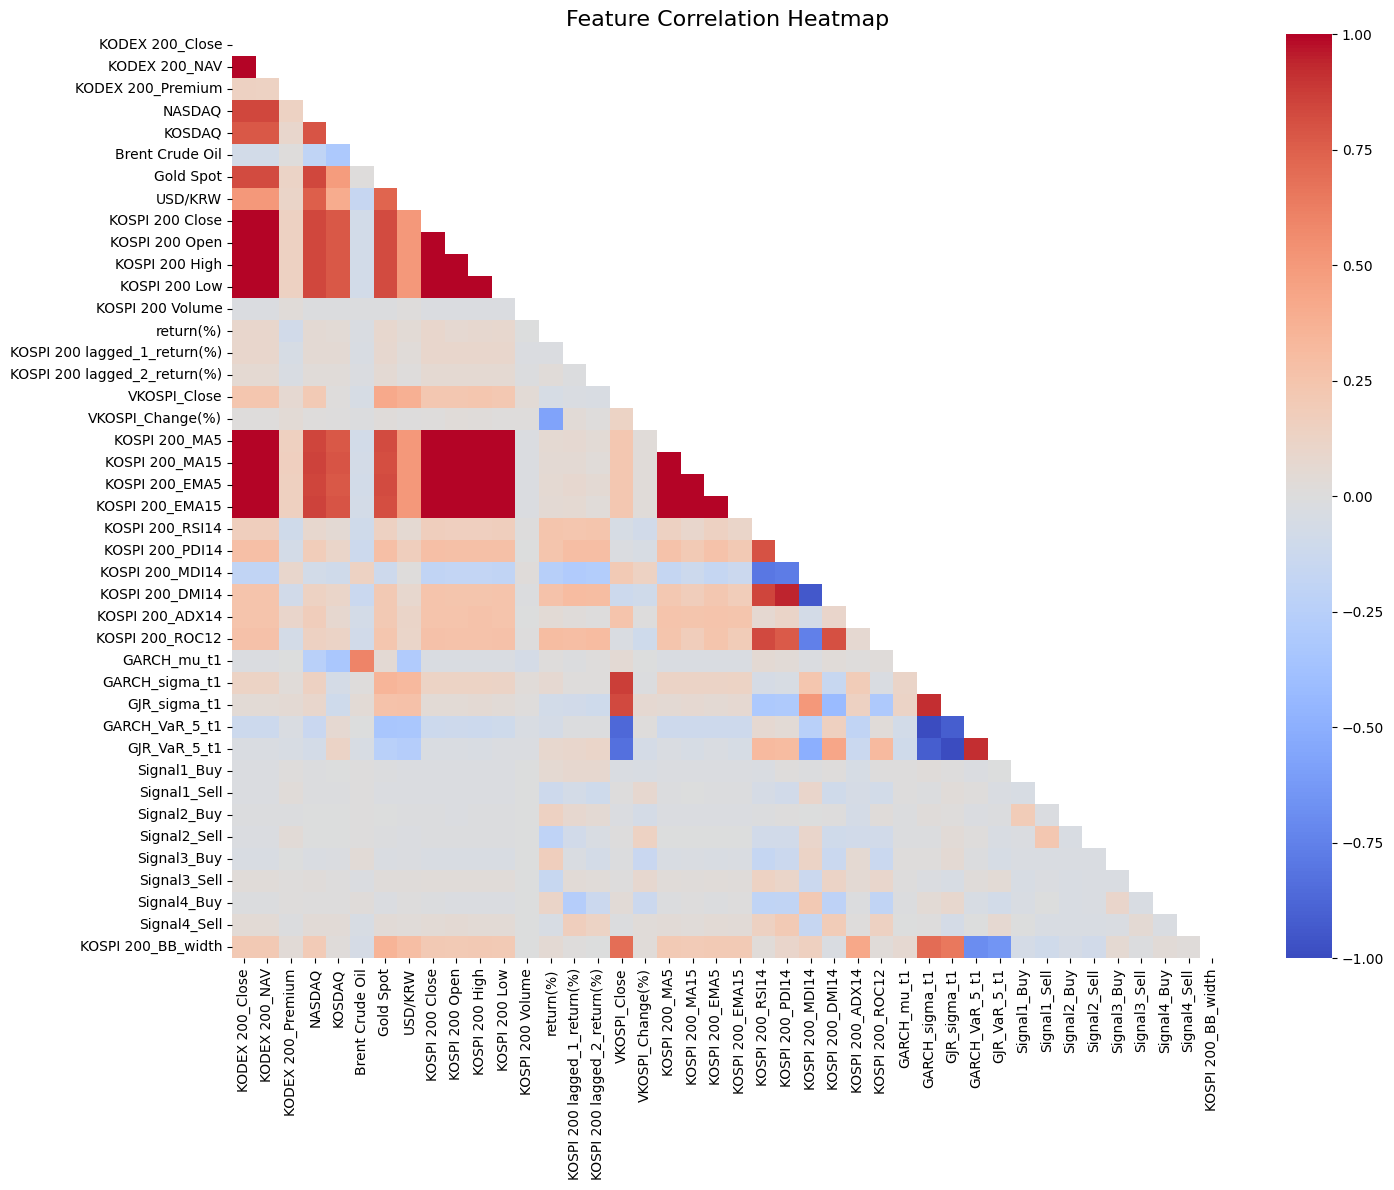


[ 📊 변수별 VIF 결과 ]


c:\Users\Owner\OneDrive\Labtop\KDISS\TS_RL_proj\venv_dt\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,KOSPI 200_DMI14,inf
1,KOSPI 200_MDI14,1125899906842624.0000
2,KOSPI 200_PDI14,102354536985693.0938
3,KODEX 200_Close,519325.1234
4,KODEX 200_NAV,512741.0978
5,KOSPI 200_EMA5,92935.5256
6,KOSPI 200_MA5,30550.6416
7,GARCH_sigma_t1,25663.2803
8,GARCH_VaR_5_t1,25438.5357
9,GJR_sigma_t1,18746.3410



🚨 VIF 10 이상인 위험 변수 목록:
['KOSPI 200_DMI14', 'KOSPI 200_MDI14', 'KOSPI 200_PDI14', 'KODEX 200_Close', 'KODEX 200_NAV', 'KOSPI 200_EMA5', 'KOSPI 200_MA5', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200 Close', 'KOSPI 200_EMA15', 'KOSPI 200_MA15', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'NASDAQ', 'KODEX 200_Premium', 'Gold Spot', 'GARCH_mu_t1', 'KOSPI 200_ROC12']


In [3]:
full_data_a = full_data.assign(
    **{'KOSPI 200_BB_width': 
       (full_data['KOSPI 200_BB_UPPER15'] - full_data['KOSPI 200_BB_LOWER15']) / full_data['KOSPI 200_BB_MID15']}).drop(columns=['KOSPI 200_BB_UPPER15','KOSPI 200_BB_LOWER15','KOSPI 200_BB_MID15'])

check_multicollinearity(full_data_a, target_col='Risk_Label')

## MDI, PDI 제거 후 VIF 확인 (full_data_b, DMI만 이용)

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 40)



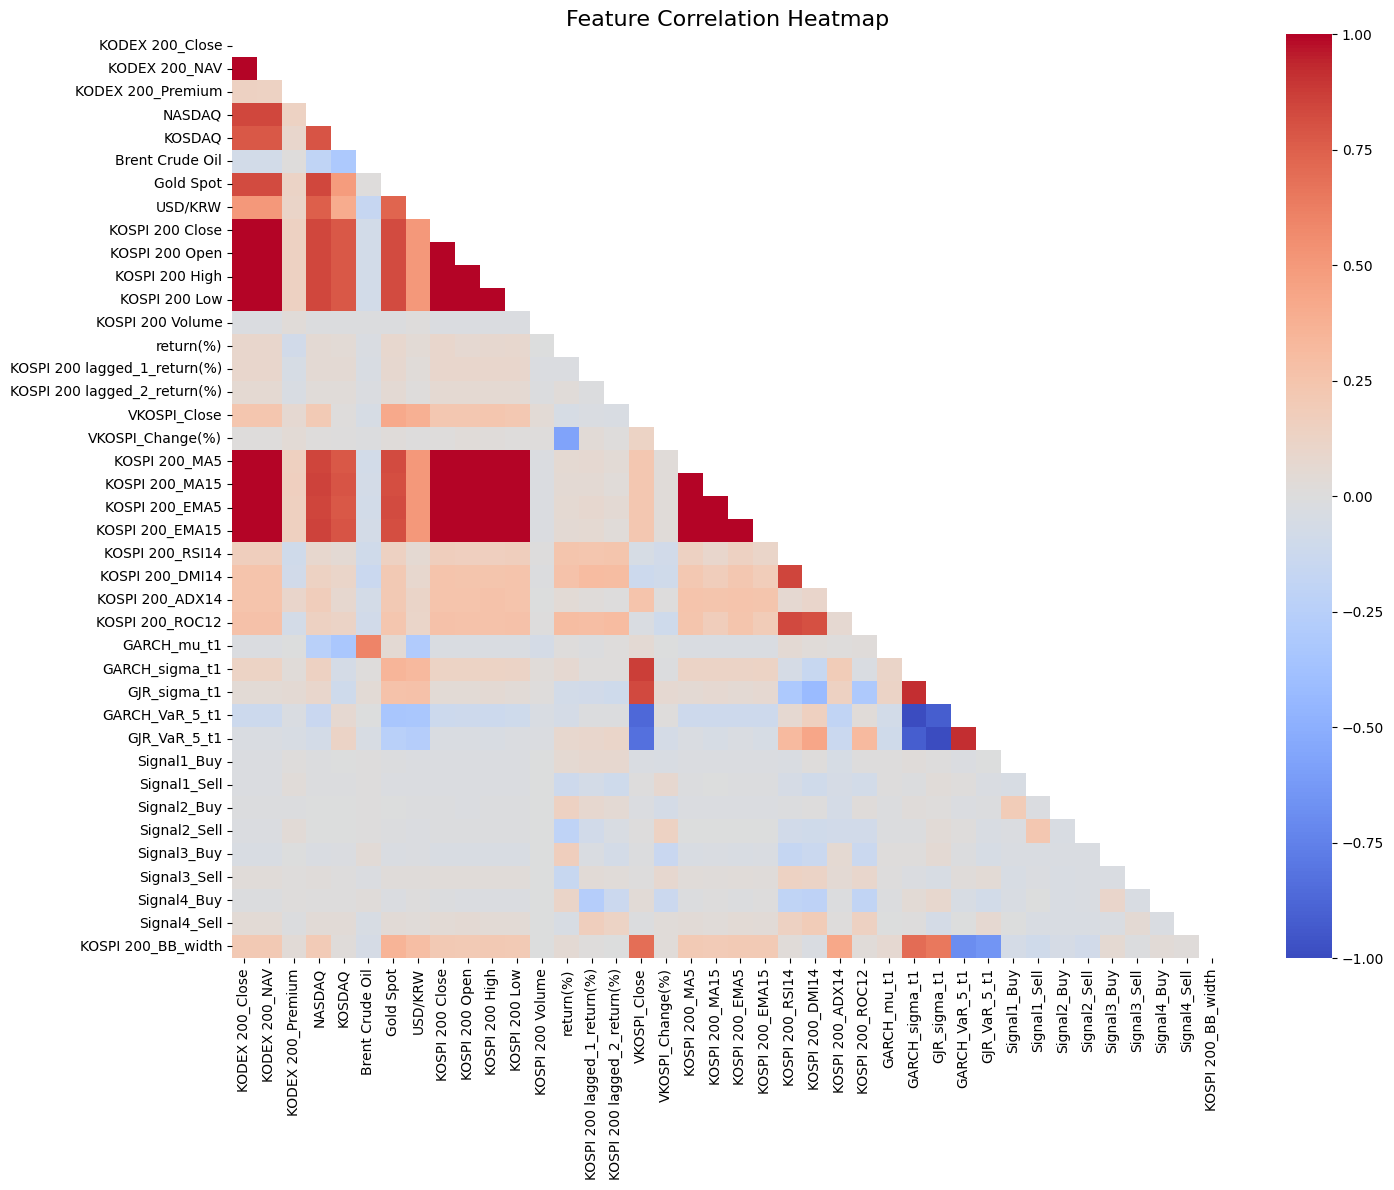


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_Close,518880.0935
1,KODEX 200_NAV,512337.3520
2,KOSPI 200_EMA5,92840.1234
3,KOSPI 200_MA5,30535.3929
4,GARCH_sigma_t1,24865.6385
5,GARCH_VaR_5_t1,24649.3830
6,GJR_sigma_t1,18359.8127
7,GJR_VaR_5_t1,18230.7442
8,KOSPI 200 Close,15917.3653
9,KOSPI 200_EMA15,8782.3666



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_Close', 'KODEX 200_NAV', 'KOSPI 200_EMA5', 'KOSPI 200_MA5', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200 Close', 'KOSPI 200_EMA15', 'KOSPI 200_MA15', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'NASDAQ', 'KODEX 200_Premium', 'Gold Spot', 'GARCH_mu_t1', 'KOSPI 200_ROC12']


In [4]:
# 1. full_data_a에서 MDI, PDI 제거 후 full_data_b에 대입
full_data_b = full_data_a.drop(columns=['KOSPI 200_MDI14', 'KOSPI 200_PDI14'], errors='ignore')

# 2. full_data_b로 VIF 함수 실행
check_multicollinearity(full_data_b, target_col='Risk_Label')

### EMA12/26 추가를 통한 PPO 계산, MA족 변수 모두 드랍 후 VIF 확인

KOSPI 200_PPO         0
KOSPI 200_PPO_Hist    0
dtype: int64
🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 38)



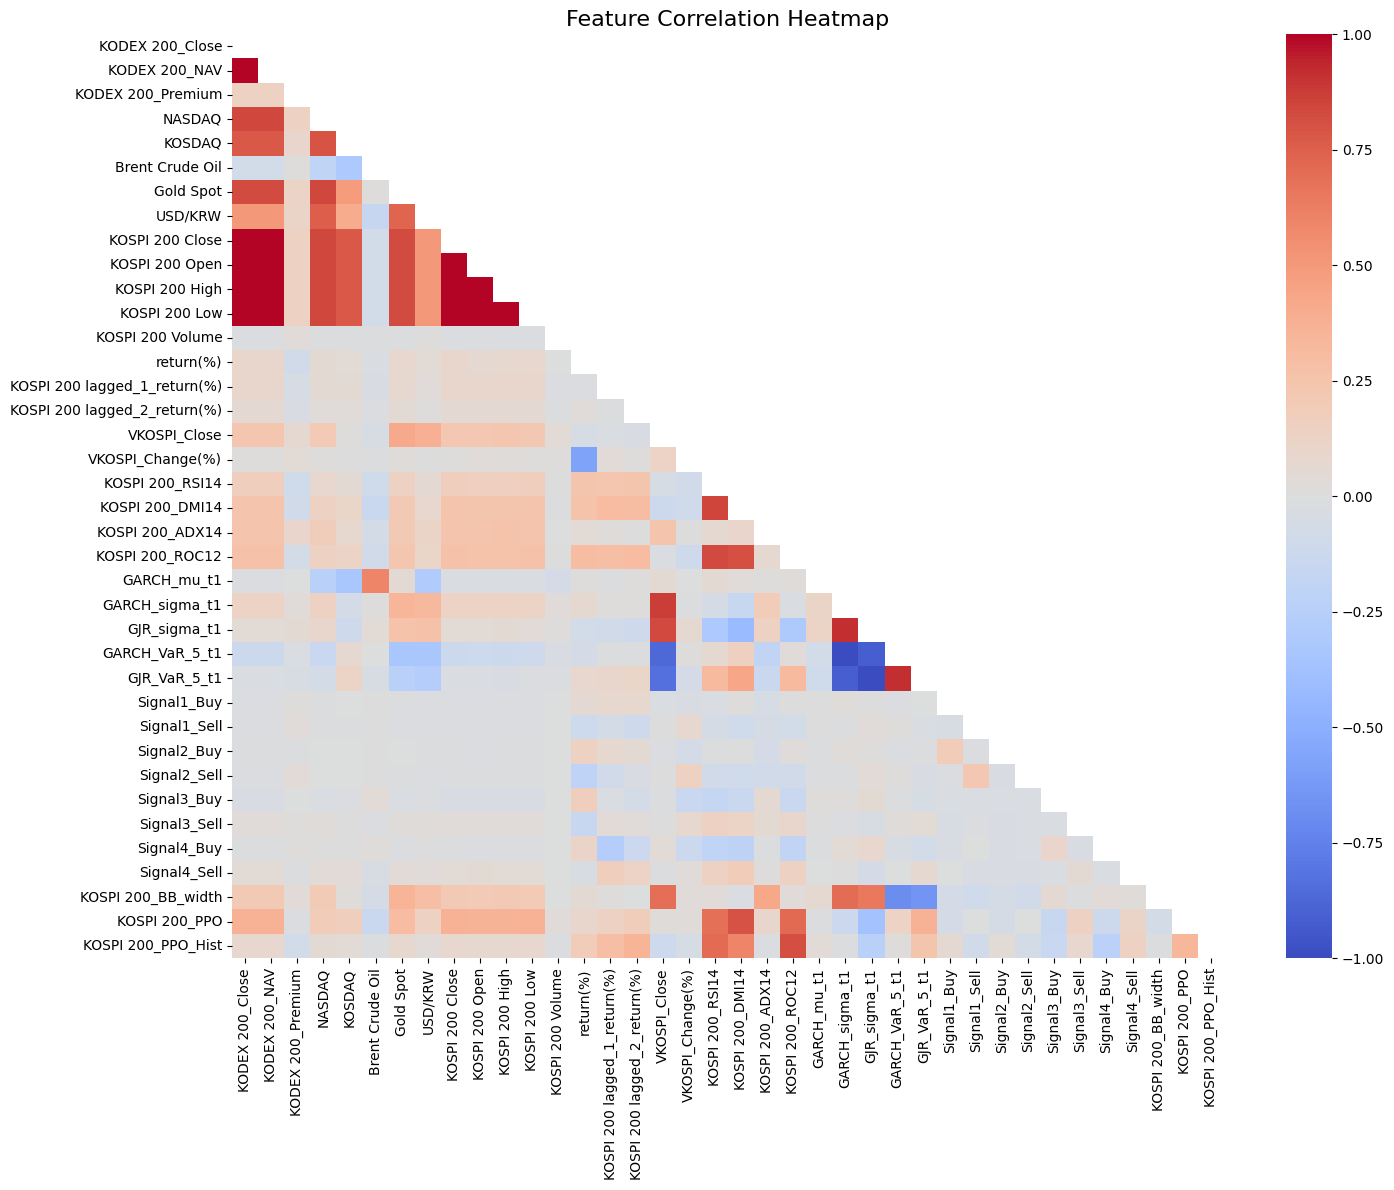


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_Close,517588.5318
1,KODEX 200_NAV,510979.7798
2,GARCH_sigma_t1,24630.9417
3,GARCH_VaR_5_t1,24423.6982
4,GJR_sigma_t1,18462.9615
5,GJR_VaR_5_t1,18327.8561
6,KOSPI 200 Close,7526.6939
7,KOSPI 200 High,6445.2349
8,KOSPI 200 Low,5071.7981
9,KOSPI 200 Open,4632.6764



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_Close', 'KODEX 200_NAV', 'GARCH_sigma_t1', 'GARCH_VaR_5_t1', 'GJR_sigma_t1', 'GJR_VaR_5_t1', 'KOSPI 200 Close', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'NASDAQ', 'KODEX 200_Premium', 'Gold Spot', 'GARCH_mu_t1', 'KOSPI 200_ROC12']


In [5]:
data_2008_test = pd.read_csv(r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

close = data_2008_test['KOSPI 200 Close']

ema12 = close.ewm(span=12, adjust=False).mean()
ema26 = close.ewm(span=26, adjust=False).mean()

# 1. PPO 계산 (PPO = (EMA12 - EMA26) / EMA26 * 100)
data_2008_test['KOSPI 200_PPO'] = (ema12 - ema26) / ema26 * 100

# 2. PPO 시그널 계산 (PPO의 9일 지수이동평균)
data_2008_test['KOSPI 200_PPO_Signal'] = (data_2008_test['KOSPI 200_PPO']
    .ewm(span=9, adjust=False).mean()
)

# 3. PPO 히스토그램 계산 (PPO - PPO 시그널)
data_2008_test['KOSPI 200_PPO_Hist'] = (data_2008_test['KOSPI 200_PPO']
    - data_2008_test['KOSPI 200_PPO_Signal']
)

# 4. full_data_b를 복사하여 full_data_c 생성 후 기존에 같은 컬럼이 있으면 제거
full_data_c = full_data_b.copy().sort_index()
full_data_c = full_data_c.drop(columns=[
    'KOSPI 200_PPO',
    'KOSPI 200_PPO_Hist'
], errors='ignore')

# 5. data_2008_test에서 필요한 컬럼(PPO, PPO_Hist)만 병합
full_data_c = full_data_c.join(
    data_2008_test[['KOSPI 200_PPO', 'KOSPI 200_PPO_Hist']],
    how='left'
)

# 6. 다중공선성의 원인이 되는 재료 변수들(이동 평균 족 변수) 일괄 삭제
full_data_c = full_data_c.drop(columns=[
    'KOSPI 200_MA5',
    'KOSPI 200_MA15',
    'KOSPI 200_EMA5',
    'KOSPI 200_EMA15'
], errors='ignore')

# 5.5 full_data_c의 변수별 결측치 확인
print(full_data_c[['KOSPI 200_PPO', 'KOSPI 200_PPO_Hist']].isna().sum())

# 6. 결과 확인 및 VIF 실행
check_multicollinearity(full_data_c, target_col='Risk_Label')

### VaR족 변수 제거

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 34)



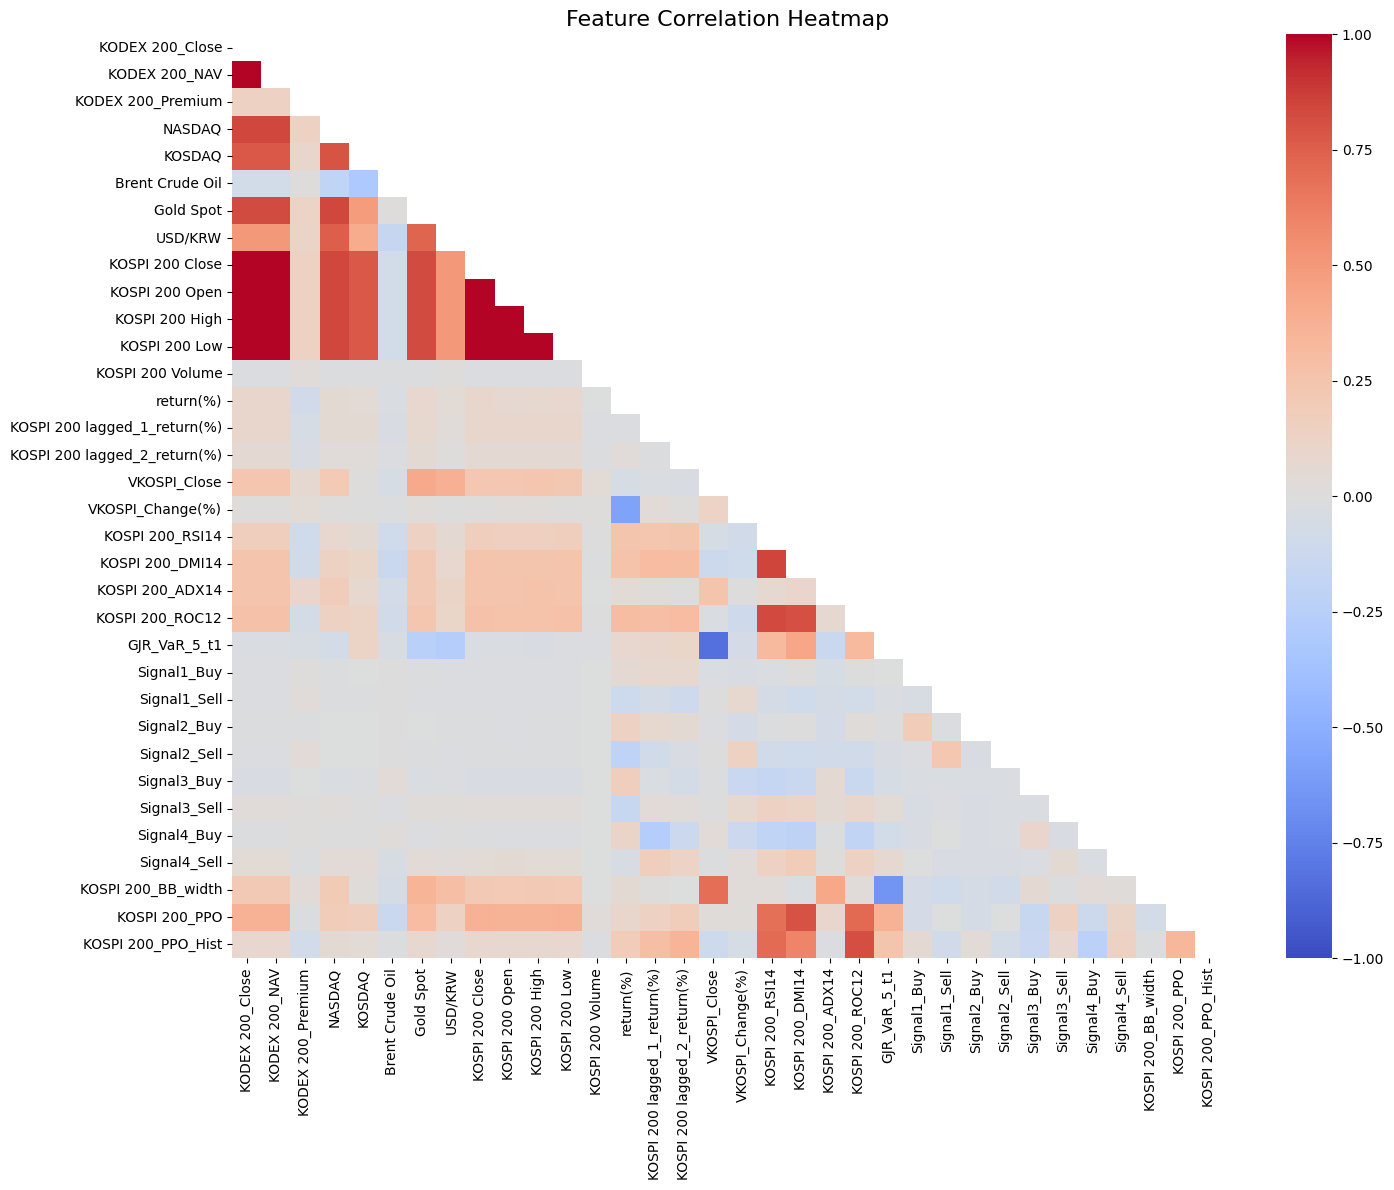


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_Close,516346.9105
1,KODEX 200_NAV,509302.2782
2,KOSPI 200 Close,7444.1115
3,KOSPI 200 High,6383.8963
4,KOSPI 200 Low,5039.9324
5,KOSPI 200 Open,4627.5212
6,KODEX 200_Premium,21.5580
7,NASDAQ,18.9497
8,Gold Spot,13.8589
9,KOSPI 200_ROC12,10.9263



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_Close', 'KODEX 200_NAV', 'KOSPI 200 Close', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Open', 'KODEX 200_Premium', 'NASDAQ', 'Gold Spot', 'KOSPI 200_ROC12']


In [6]:
full_data_d = full_data_c.copy().sort_index()

full_data_d = full_data_d.drop(columns=[
    "GARCH_sigma_t1",
    "GJR_sigma_t1",
    "GARCH_mu_t1",
    "GARCH_VaR_5_t1"
], errors="ignore")

# GARCH_sigma_t1과 GARCH_VaR_5_t1은 선형 종속관계이며, 
# GJR_sigma_t1과 GARCH_mu_t1도 VIF가 높게 나와서 제거했다.
# GARCH_VaR_5_t1과 GJR_VaR_5_t1 중 더 중요한 GJR_VaR_5_t1은 남겨두었다.

# VIF 재확인
check_multicollinearity(full_data_d, target_col="Risk_Label")

### Open을 이용한 파생변수 Overnight Gap 생성 후, OHLC 제거

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 31)



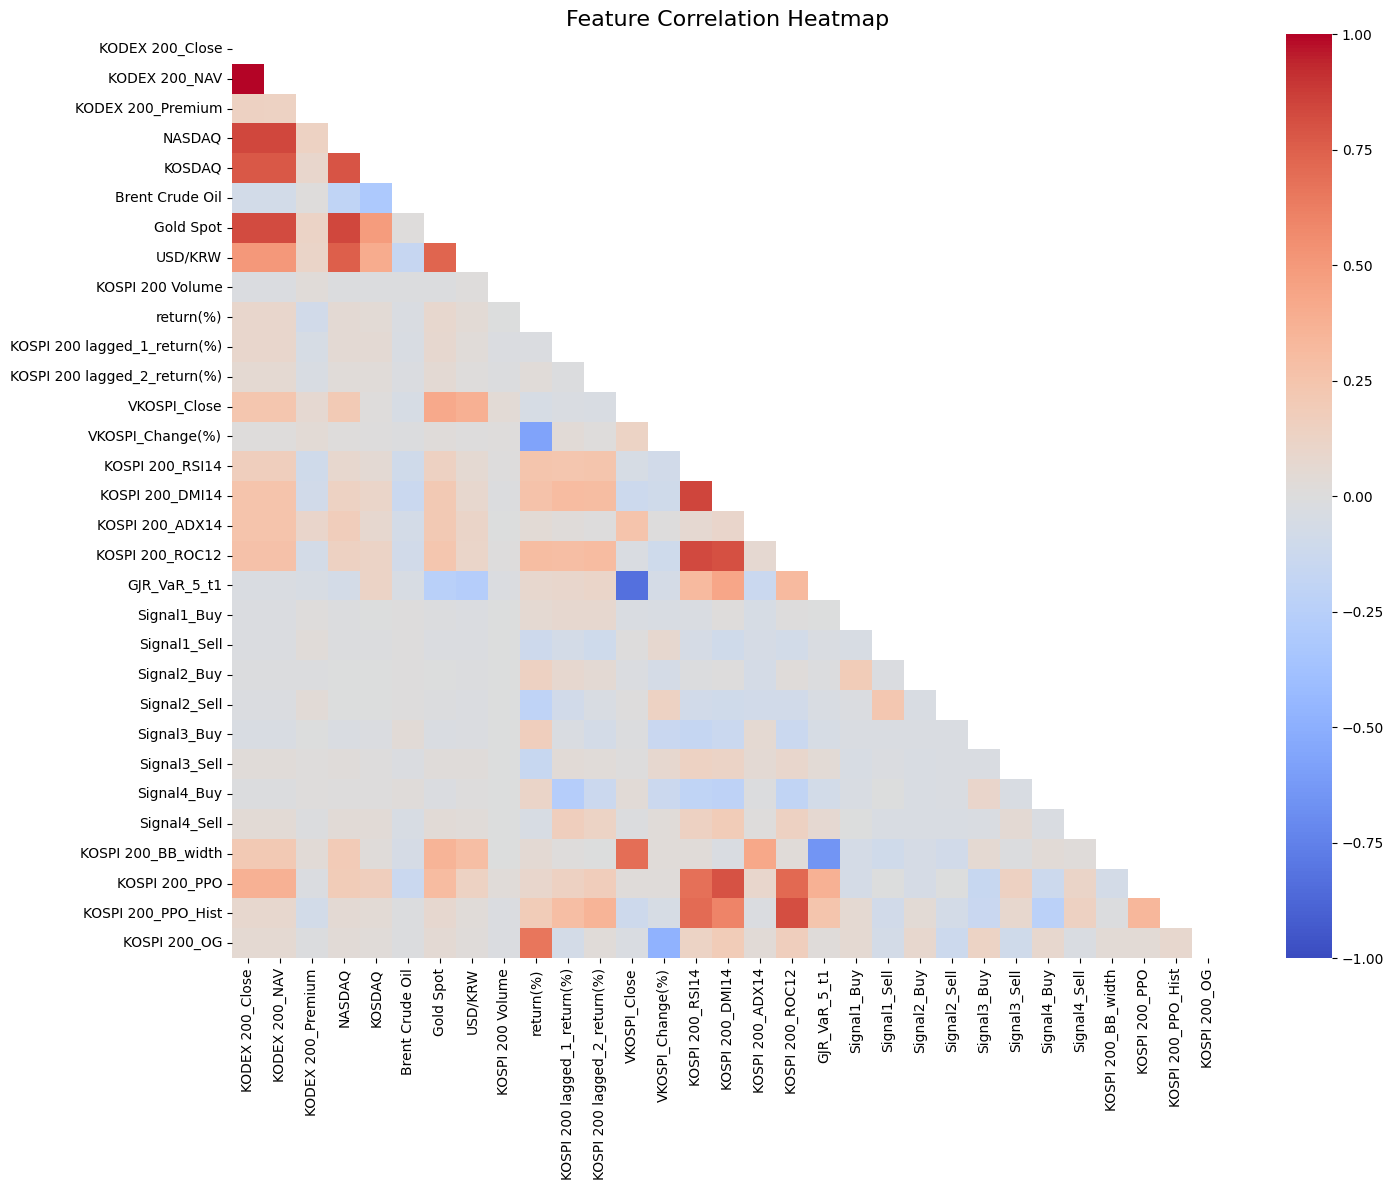


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_Close,505301.8950
1,KODEX 200_NAV,504777.0156
2,KODEX 200_Premium,21.2366
3,NASDAQ,18.6911
4,Gold Spot,13.7669
5,KOSPI 200_ROC12,10.9039
6,KOSDAQ,9.2844
7,KOSPI 200_DMI14,8.1119
8,KOSPI 200_PPO,7.6542
9,GJR_VaR_5_t1,7.3880



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_Close', 'KODEX 200_NAV', 'KODEX 200_Premium', 'NASDAQ', 'Gold Spot', 'KOSPI 200_ROC12']


In [7]:
data_2008_test = pd.read_csv(
    r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

full_data_e = full_data_d.copy().sort_index()

# 기존 OG 컬럼이 있으면 제거
full_data_e = full_data_e.drop(columns=['KOSPI 200_OG'], errors='ignore')

# 1. 전일 종가
prev_close = data_2008_test['KOSPI 200 Close'].shift(1)

# 2. Overnight Gap 계산
data_2008_test['KOSPI 200_OG'] = (
    (data_2008_test['KOSPI 200 Open'] - prev_close)
    / prev_close
) * 100

# 3. 날짜 인덱스 기준 병합
full_data_e = full_data_e.join(
    data_2008_test[['KOSPI 200_OG']],
    how='left'
)

# 4. full_data_e의 OHLC 컬럼 제거
full_data_e = full_data_e.drop(
    columns=['KOSPI 200 Open', 'KOSPI 200 High', 'KOSPI 200 Low', 'KOSPI 200 Close'])

# VIF 확인
check_multicollinearity(full_data_e, target_col="Risk_Label")

### NASDAQ / Gold Spot의 로그 수익률화 및 ROC12 제거

결측치 확인:
NASDAQ_return(%)       0
Gold Spot_return(%)    0
dtype: int64
row count: 4108 -> 4108
🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 30)



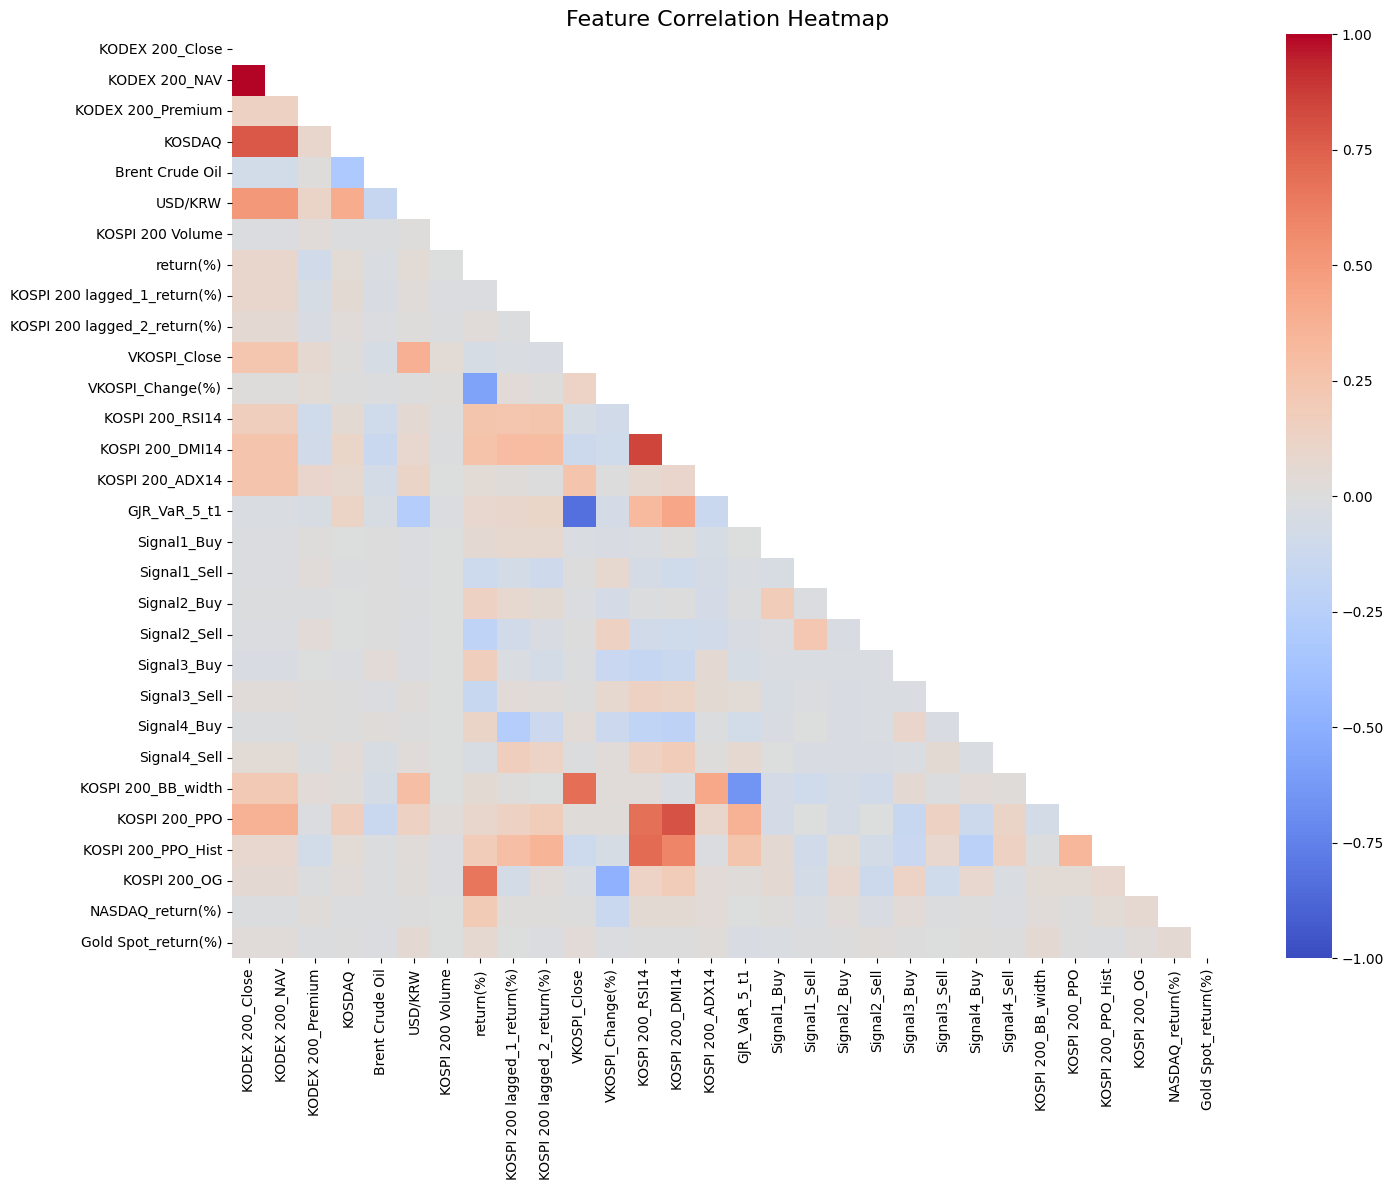


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_Close,496192.2679
1,KODEX 200_NAV,495667.9827
2,KODEX 200_Premium,20.7993
3,KOSPI 200_DMI14,8.0172
4,GJR_VaR_5_t1,7.3379
5,VKOSPI_Close,6.3453
6,KOSPI 200_RSI14,5.3012
7,KOSPI 200_PPO,5.1092
8,KOSDAQ,4.2371
9,KOSPI 200_BB_width,2.7411



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_Close', 'KODEX 200_NAV', 'KODEX 200_Premium']


In [8]:
# =========================
# 1. 2008년부터의 raw 데이터 불러오기
# =========================
data_2008_test = pd.read_csv(
    r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

# =========================
# 2. NASDAQ, Gold Spot 변화율 생성
#    log(P_t / P_{t-1}) * 100
# =========================
data_2008_test["NASDAQ_return(%)"] = (
    np.log(data_2008_test["NASDAQ"] / data_2008_test["NASDAQ"].shift(1)) * 100
)
data_2008_test["Gold Spot_return(%)"] = (
    np.log(data_2008_test["Gold Spot"] / data_2008_test["Gold Spot"].shift(1)) * 100
)

# =========================
# 3. 현재 분석 데이터 복사
# =========================
full_data_f = full_data_e.copy().sort_index()

# =========================
# 4. 기존 return 컬럼이 있으면 제거
# =========================
full_data_f = full_data_f.drop(columns=[
    "NASDAQ_return(%)",
    "Gold Spot_return(%)",
    "KOSPI 200_ROC12"
], errors="ignore")

# =========================
# 5. 날짜 인덱스 기준으로 변화율 변수 병합
# =========================
full_data_f = full_data_f.join(
    data_2008_test[["NASDAQ_return(%)", "Gold Spot_return(%)"]],
    how="left"
)

# =========================
# 6. 원 변수 제거
# =========================
full_data_f = full_data_f.drop(columns=[
    "NASDAQ",
    "Gold Spot"
], errors="ignore")

# =========================
# 7. 병합 결과 확인
# =========================
print("결측치 확인:")
print(full_data_f[["NASDAQ_return(%)", "Gold Spot_return(%)"]].isna().sum())
print("row count:", len(full_data_e), "->", len(full_data_f))

# =========================
# 8. VIF 확인
# =========================
check_multicollinearity(full_data_f, target_col="Risk_Label")


### KOSDAQ / Brent Crude Oil / USD/KRW도 수익률 및 변화량으로 변환

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 30)



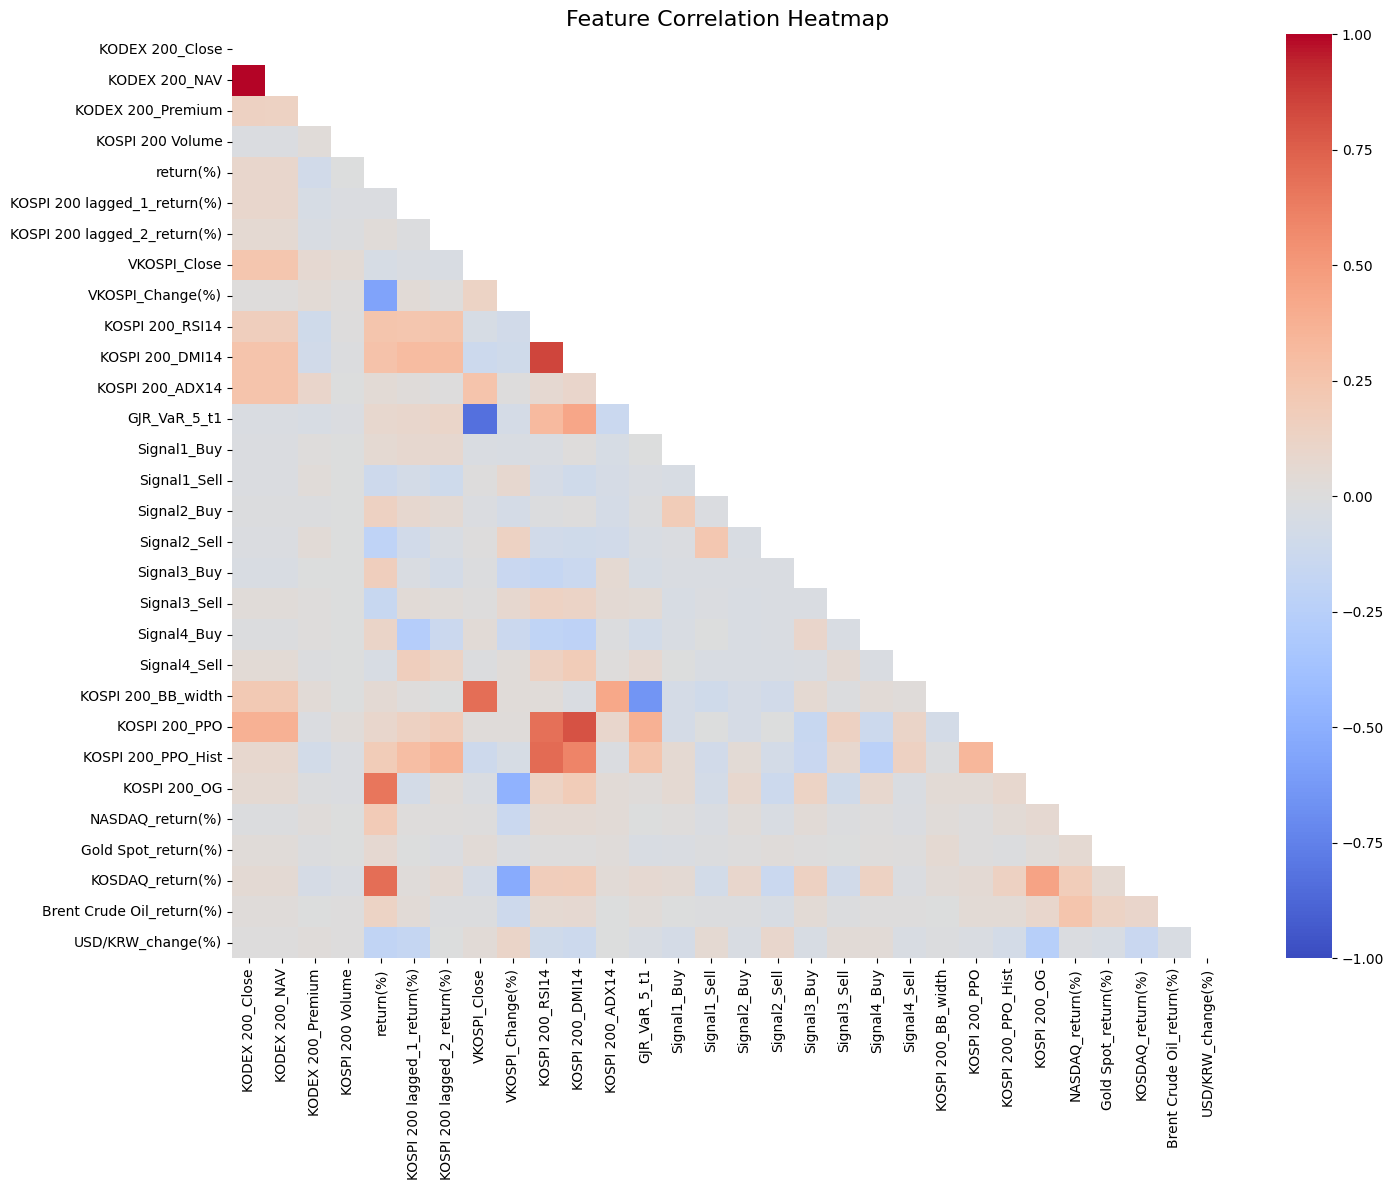


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KODEX 200_Close,483790.1126
1,KODEX 200_NAV,482860.6677
2,KODEX 200_Premium,20.3630
3,KOSPI 200_DMI14,7.9299
4,GJR_VaR_5_t1,7.0974
5,VKOSPI_Close,6.2459
6,KOSPI 200_RSI14,5.2954
7,KOSPI 200_PPO,4.8632
8,return(%),3.2661
9,KOSPI 200_BB_width,2.7319



🚨 VIF 10 이상인 위험 변수 목록:
['KODEX 200_Close', 'KODEX 200_NAV', 'KODEX 200_Premium']


In [9]:
# =========================
# 1. 2008년부터의 raw 데이터 불러오기
# =========================
data_2008_test = pd.read_csv(
    r'..\..\data\raw\data_2008.csv',
    index_col=0,
    parse_dates=True
).sort_index()

# =========================
# 2. KOSDAQ / Brent Crude Oil / USD/KRW 변환
#    KODEX 200, KOSDAQ, Brent: 로그수익률
#    USD/KRW: 로그변화율
# =========================
data_2008_test["KOSDAQ_return(%)"] = (
    np.log(data_2008_test["KOSDAQ"] / data_2008_test["KOSDAQ"].shift(1)) * 100
)

data_2008_test["Brent Crude Oil_return(%)"] = (
    np.log(data_2008_test["Brent Crude Oil"] / data_2008_test["Brent Crude Oil"].shift(1)) * 100
)

data_2008_test["USD/KRW_change(%)"] = (
    np.log(data_2008_test["USD/KRW"] / data_2008_test["USD/KRW"].shift(1)) * 100
)

# =========================
# 3. 현재 분석 데이터 복사
# =========================
full_data_g = full_data_f.copy().sort_index()

# =========================
# 4. 기존 변환 컬럼이 있으면 제거
# =========================
new_cols = [
    "KOSDAQ_return(%)",
    "Brent Crude Oil_return(%)",
    "USD/KRW_change(%)"
]

full_data_g = full_data_g.drop(columns=new_cols, errors="ignore")

# =========================
# 5. 날짜 인덱스 기준으로 변환 변수 병합
# =========================
full_data_g = full_data_g.join(
    data_2008_test[new_cols],
    how="left"
)

# =========================
# 6. 원레벨 변수 제거
# =========================
full_data_g = full_data_g.drop(columns=[
    "KOSDAQ",
    "Brent Crude Oil",
    "USD/KRW"
], errors="ignore")

# =========================
# 7. VIF 확인
# =========================
check_multicollinearity(full_data_g, target_col="Risk_Label")

### KODEX 200_Premium(괴리율)만 남기기

🚀 다중공선성(Multicollinearity) 분석 시작
✅ 분석에 사용된 데이터 형태 (결측치 제외, 숫자형만): (4108, 28)



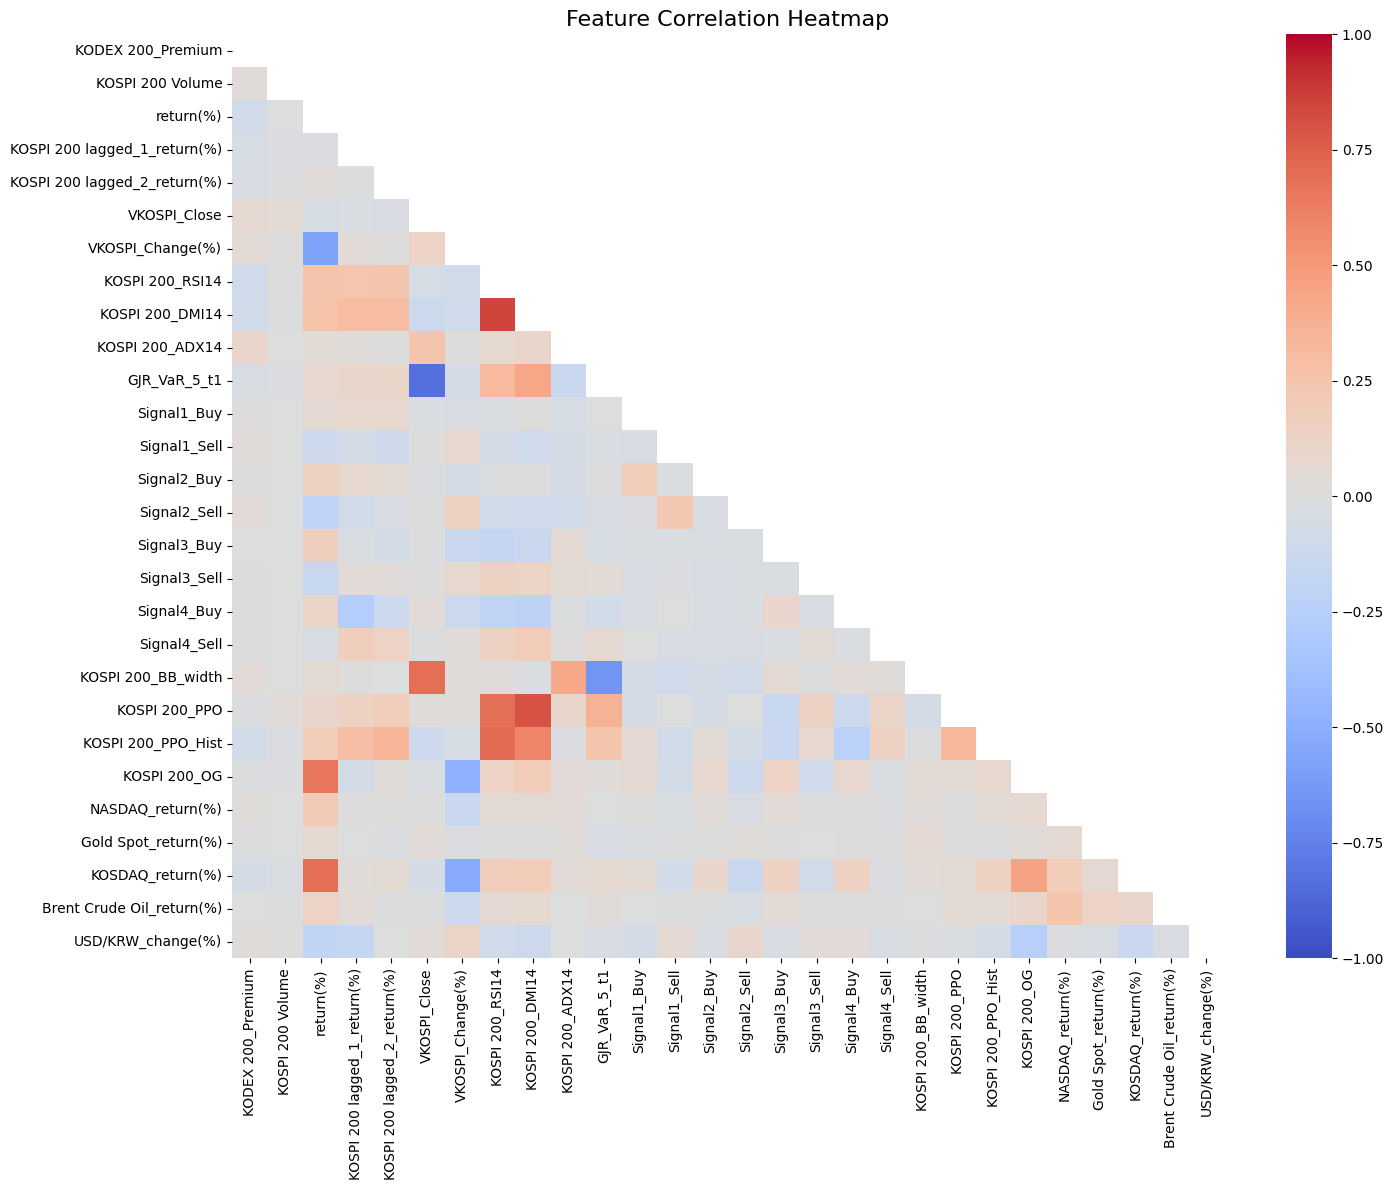


[ 📊 변수별 VIF 결과 ]


,Feature,VIF
0,KOSPI 200_DMI14,7.8863
1,GJR_VaR_5_t1,7.0495
2,VKOSPI_Close,6.1770
3,KOSPI 200_RSI14,5.2118
4,KOSPI 200_PPO,4.5402
5,return(%),3.2420
6,KOSPI 200_BB_width,2.6984
7,KOSPI 200_PPO_Hist,2.5523
8,KOSDAQ_return(%),2.0460
9,KOSPI 200_OG,1.9809



🚨 VIF 10 이상인 위험 변수 목록:
위험 수준의 변수가 없습니다. (모든 VIF 10 미만)


In [10]:
# =========================
# 1. 현재 분석 데이터 복사
# =========================
full_data_h = full_data_g.copy().sort_index()

# =========================
# 2. KODEX의 종가(Close) 및 순자산가치(NAV) 변수 제거
# =========================
full_data_h = full_data_h.drop(columns=[
    "KODEX 200_Close",
    "KODEX 200_NAV"
], errors="ignore")

# =========================
# 3. VIF 확인
# =========================
check_multicollinearity(full_data_h, target_col="Risk_Label")

### 변수 재정렬

In [11]:
new_order = [
    'KODEX 200_Premium','KOSDAQ_return(%)','NASDAQ_return(%)','Brent Crude Oil_return(%)',
    'Gold Spot_return(%)','USD/KRW_change(%)',
    
    'KOSPI 200 Volume',

    'return(%)',
    'KOSPI 200 lagged_1_return(%)',
    'KOSPI 200 lagged_2_return(%)',

    'VKOSPI_Close',
    'VKOSPI_Change(%)',

    'KOSPI 200_RSI14',
    'KOSPI 200_DMI14',
    'KOSPI 200_ADX14',
    'KOSPI 200_BB_width',
    'KOSPI 200_PPO',
    'KOSPI 200_PPO_Hist',
    'KOSPI 200_OG',

    'GJR_VaR_5_t1',

    'Signal1_Buy',
    'Signal1_Sell',
    'Signal2_Buy',
    'Signal2_Sell',
    'Signal3_Buy',
    'Signal3_Sell',
    'Signal4_Buy',
    'Signal4_Sell',

    'Risk_Label'
]

# 혹시 누락/오타 체크
missing_cols = [col for col in new_order if col not in full_data_h.columns]
extra_cols = [col for col in full_data_h.columns if col not in new_order]

print("누락된 컬럼:", missing_cols)
print("추가 컬럼:", extra_cols)

# 재배치
data_vif = full_data_h[new_order]

# 데이터 저장
data_vif.to_csv("../../data/processed/data_vif.csv", index=True)

누락된 컬럼: []
추가 컬럼: []
